# Module 1: Intent Classification
### Fine-Tuning RoBERTa on CLINC-OOS

## Install Packages

In [1]:
!pip install datasets==2.18.0 transformers accelerate sentencepiece
!pip install evaluate scikit-learn
!pip install pandas matplotlib seaborn tqdm
!pip install numpy==1.26.4

## Import Libraries

In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import evaluate
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
)
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

BASE_DIR = Path("./nlu_models")
BASE_DIR.mkdir(exist_ok=True)

INTENT_DIR = BASE_DIR / "intent_classifier"
INTENT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
print(f"Model will be saved in: {INTENT_DIR.absolute()}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Model will be saved in: /content/nlu_models/intent_classifier


## 1.1 Load & Explore Dataset

In [3]:
ds_intent_raw = load_dataset("clinc_oos", "plus")
print(ds_intent_raw)

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})


In [4]:
print(ds_intent_raw["train"].features)

df_sample = pd.DataFrame(ds_intent_raw["train"].select(range(5)))
display(df_sample)

{'text': Value(dtype='string', id=None), 'intent': ClassLabel(names=['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'measurement_conversion', 'timer', 'flip_coin', 'do_you_have_pets', 'balance', 'tell_joke', 'last_maintenance', 'exchange_rate', 'uber', 'car_rental', 'credit_limit', 'oos', 'shopping_list', 'expiration_date', 'routing', 'meal_suggestion', 'tire_change', 'todo_list', 'card_declined', 'rewards_balance', 'change_accent', 'vaccines', 'reminder_update', 'food_last', 'change_ai_name', 'bill_due', 'who_do_you_work_for', 'share_locati

,text,intent
0,what expression would i use to say i love you ...,61
1,can you tell me how to say 'i do not speak muc...,61
2,"what is the equivalent of, 'life is good' in f...",61
3,"tell me how to say, 'it is a beautiful morning...",61
4,"if i were mongolian, how would i say that i am...",61


## 1.2 EDA — Exploratory Data Analysis

In [5]:
df_intent_train = pd.DataFrame(ds_intent_raw["train"])
df_intent_val   = pd.DataFrame(ds_intent_raw["validation"])
df_intent_test  = pd.DataFrame(ds_intent_raw["test"])

print(f"Train size:      {len(df_intent_train):,}")
print(f"Validation size: {len(df_intent_val):,}")
print(f"Test size:       {len(df_intent_test):,}")

label_names_intent = ds_intent_raw["train"].features["intent"].names
print(f"\nIntent Labels ({len(label_names_intent)}): {label_names_intent}")

Train size:      15,250
Validation size: 3,100
Test size:       5,500

Intent Labels (151): ['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'measurement_conversion', 'timer', 'flip_coin', 'do_you_have_pets', 'balance', 'tell_joke', 'last_maintenance', 'exchange_rate', 'uber', 'car_rental', 'credit_limit', 'oos', 'shopping_list', 'expiration_date', 'routing', 'meal_suggestion', 'tire_change', 'todo_list', 'card_declined', 'rewards_balance', 'change_accent', 'vaccines', 'reminder_update', 'food_last', 'change_ai_name', 'bill_due', 'who_do_you_

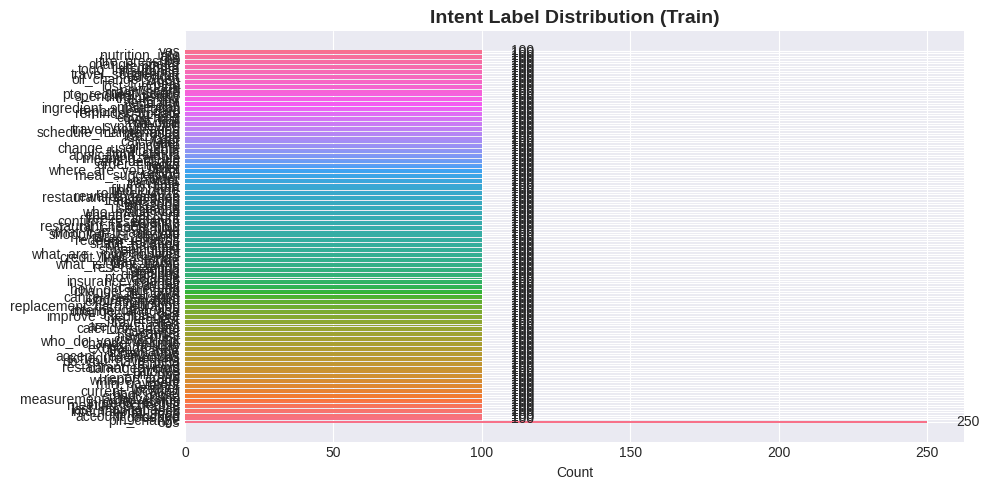

In [6]:
label_counts = df_intent_train["intent"].value_counts()
label_names_mapped = [label_names_intent[i] for i in label_counts.index]

plt.figure(figsize=(10, 5))
plt.barh(label_names_mapped, label_counts.values,
         color=sns.color_palette("husl", len(label_counts)))
plt.title("Intent Label Distribution (Train)", fontsize=14, fontweight="bold")
plt.xlabel("Count")
for i, v in enumerate(label_counts.values):
    plt.text(v + 10, i, str(v), va="center")
plt.tight_layout()
plt.show()

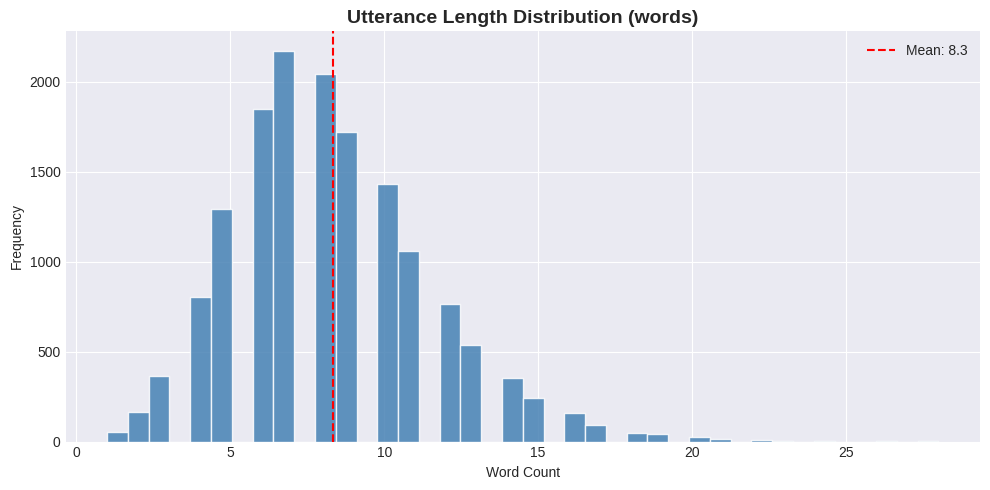

In [7]:
df_intent_train["utt_len"] = df_intent_train["text"].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(df_intent_train["utt_len"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)

mean_len = df_intent_train["utt_len"].mean()
plt.axvline(mean_len, color="red", linestyle="--", label=f"Mean: {mean_len:.1f}")
plt.title("Utterance Length Distribution (words)", fontsize=14, fontweight="bold")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 1.3 Data Cleaning

In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"[^\w\s\?\!\.\,\;\:\'\-]", "", text)
    text = text.lower()
    return text

def clean_dataset_split(dataset_split):
    df = pd.DataFrame(dataset_split)
    original_length = len(df)
    df["text"] = df["text"].apply(clean_text)
    df = df[df["text"].str.len() > 2].reset_index(drop=True)
    df["word_count"] = df["text"].str.split().str.len()
    df = df[df["word_count"] <= 200].drop(columns=["word_count"])
    print(f"Removed {original_length - len(df)} rows ({original_length} -> {len(df)})")
    return Dataset.from_pandas(df[["text", "intent"]], preserve_index=False)

ds_intent_clean = DatasetDict({
    "train":      clean_dataset_split(ds_intent_raw["train"]),
    "validation": clean_dataset_split(ds_intent_raw["validation"]),
    "test":       clean_dataset_split(ds_intent_raw["test"]),
})

print(ds_intent_clean)

Removed 2 rows (15250 -> 15248)
Removed 1 rows (3100 -> 3099)
Removed 1 rows (5500 -> 5499)
DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15248
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3099
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5499
    })
})


## 1.4 Tokenization with RoBERTa

In [9]:
MODEL_NAME = "roberta-base"
print(f"Loading tokenizer: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

ds_intent_tok = ds_intent_clean.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing dataset"
)

ds_intent_tok = ds_intent_tok.rename_column("intent", "labels")
ds_intent_tok.set_format("torch")

print(ds_intent_tok)

Loading tokenizer: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset:   0%|          | 0/15248 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/3099 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/5499 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 15248
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 3099
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5499
    })
})


## 1.5 Fine-Tuning RoBERTa for Intent Classification

In [10]:
num_labels = len(label_names_intent)
id2label = {i: label for i, label in enumerate(label_names_intent)}
label2id = {label: i for i, label in enumerate(label_names_intent)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Total parameters:     124,761,751
Trainable parameters: 124,761,751


In [11]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": accuracy, "f1_weighted": f1}

In [12]:
output_dir = str(INTENT_DIR)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=500,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
    dataloader_num_workers=2,
)

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_intent_tok["train"],
    eval_dataset=ds_intent_tok["validation"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Model: {MODEL_NAME}")
print(f"Train samples: {len(ds_intent_tok['train']):,}")
print(f"Validation samples: {len(ds_intent_tok['validation']):,}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")

train_result = trainer.train()

print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Runtime (s):   {train_result.metrics['train_runtime']:.0f}")
print(f"Samples/sec:   {train_result.metrics['train_samples_per_second']:.1f}")

Model: roberta-base
Train samples: 15,248
Validation samples: 3,099
Epochs: 5
Batch size: 32
Learning rate: 2e-05


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,3.239554,2.589961,0.812197,0.794019
2,0.880378,0.663371,0.940949,0.938404
3,0.320841,0.310702,0.958696,0.958211
4,0.150101,0.236562,0.961278,0.960979
5,0.127803,0.229940,0.962569,0.962262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Training loss: 1.3444
Runtime (s):   539
Samples/sec:   141.4


## 1.6 Testing & Evaluation

In [14]:
print("Evaluating on TEST set")
test_results = trainer.evaluate(ds_intent_tok["test"])

print("\nTest Results:")
for k, v in test_results.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Evaluating on TEST set



Test Results:
  eval_loss: 0.5378
  eval_accuracy: 0.9014
  eval_f1_weighted: 0.8973
  eval_runtime: 8.1811
  eval_samples_per_second: 672.1600
  eval_steps_per_second: 10.5120
  epoch: 5.0000


In [15]:
predictions_output = trainer.predict(ds_intent_tok["test"])

y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

print("\nFull Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_names_intent))


Full Classification Report:
                           precision    recall  f1-score   support

       restaurant_reviews       0.87      0.87      0.87        30
           nutrition_info       0.77      1.00      0.87        30
          account_blocked       0.97      0.93      0.95        30
           oil_change_how       0.88      0.97      0.92        30
                     time       0.91      1.00      0.95        30
                  weather       0.86      1.00      0.92        30
           redeem_rewards       0.93      0.83      0.88        30
            interest_rate       0.78      0.97      0.87        30
                 gas_type       0.97      1.00      0.98        30
      accept_reservations       0.87      0.90      0.89        30
               smart_home       0.75      1.00      0.86        30
                user_name       0.94      0.97      0.95        30
         report_lost_card       1.00      0.93      0.97        30
                   repeat       

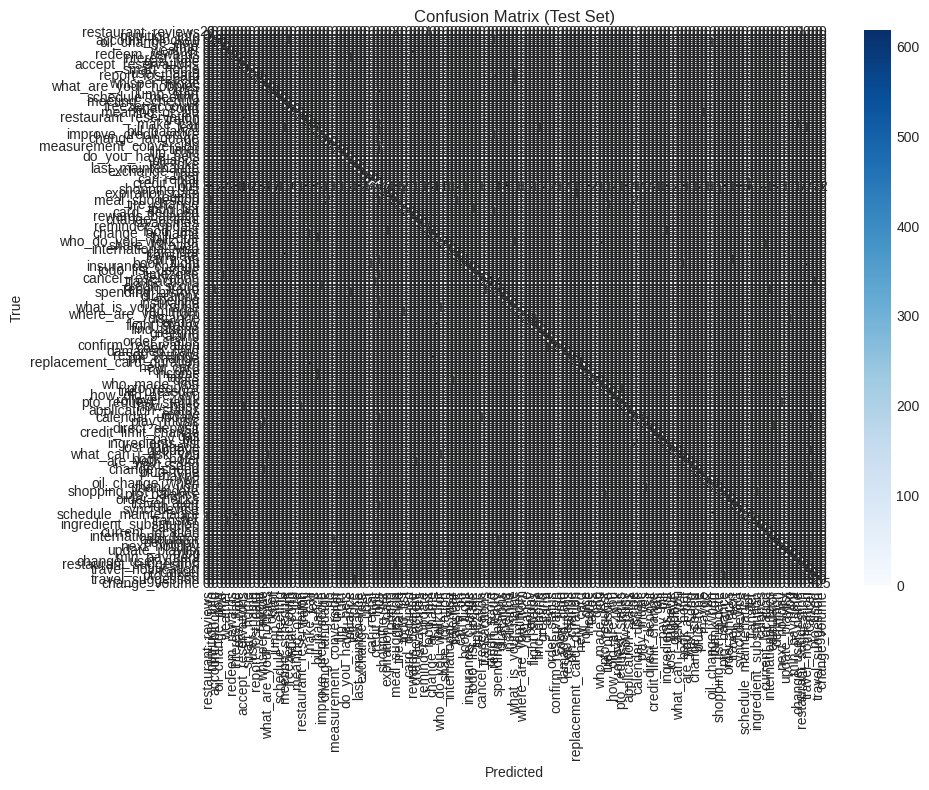

In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names_intent,
    yticklabels=label_names_intent,
    ax=ax
)
ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

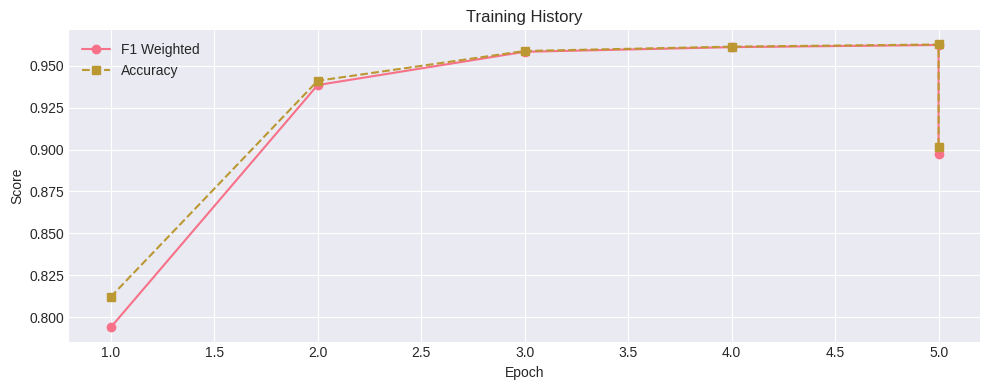

In [17]:
history = [
    (e["epoch"], e.get("eval_f1_weighted"), e.get("eval_accuracy"))
    for e in trainer.state.log_history
    if "eval_f1_weighted" in e
]

if history:
    epochs, f1s, accs = zip(*history)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, f1s, "o-", label="F1 Weighted")
    ax.plot(epochs, accs, "s--", label="Accuracy")
    ax.set_title("Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
MAX_LEN_INTENT = 128

test_utterances = [
    "Can you please send me the updated project timeline by end of day?",
    "I will complete the API integration before next sprint.",
    "What was the budget allocated for Q3 marketing?",
    "The deployment failed due to a misconfigured environment variable.",
    "Let's schedule a follow-up meeting for Thursday at 2 PM.",
    "I need someone to review the security audit report.",
]

model.eval()

for utt in test_utterances:
    enc = tokenizer(
        utt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN_INTENT
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**enc).logits

    probs = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    confidence = probs[pred_id].item()

    print(f"Text: {utt}")
    print(f"Prediction: {id2label[pred_id]} (confidence: {confidence:.4f})\n")

Text: Can you please send me the updated project timeline by end of day?
Prediction: meeting_schedule (confidence: 0.0987)

Text: I will complete the API integration before next sprint.
Prediction: oos (confidence: 0.2773)

Text: What was the budget allocated for Q3 marketing?
Prediction: income (confidence: 0.3278)

Text: The deployment failed due to a misconfigured environment variable.
Prediction: account_blocked (confidence: 0.1272)

Text: Let's schedule a follow-up meeting for Thursday at 2 PM.
Prediction: schedule_meeting (confidence: 0.9384)

Text: I need someone to review the security audit report.
Prediction: vaccines (confidence: 0.1227)



## 1.7 Save Intent Model

In [19]:
import json

trainer.save_model(str(INTENT_DIR))
tokenizer.save_pretrained(str(INTENT_DIR))

label_config = {"id2label": id2label, "label2id": label2id}
with open(INTENT_DIR / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print(f"Model saved to: {INTENT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: nlu_models/intent_classifier
